In [15]:
# Core libraries
import os
import shutil
import uuid
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Image saving
from PIL import Image

In [16]:
# Hardcoded dataset paths (as requested)
source_dir = r"C:\Users\javie\Downloads\archive (10)\PlantVillage"
target_dir = r"C:\Users\javie\Documents\BIP2\potato_only"

# Classes to keep
classes_to_keep = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

# Create filtered dataset directory
os.makedirs(target_dir, exist_ok=True)

# Copy only selected classes
for cls in classes_to_keep:
    src = os.path.join(source_dir, cls)
    dst = os.path.join(target_dir, cls)
    shutil.copytree(src, dst, dirs_exist_ok=True)

print("Dataset prepared")

Dataset prepared


In [17]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

In [18]:
# Load training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    target_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    target_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [20]:
# Apply random transformations to improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [21]:
# MobileNetV2 expects inputs in range [-1, 1]
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [24]:
# Load pretrained base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model (initial training phase)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),  # 👈 SOLUCIÓN
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

In [25]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_4 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_4   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_8 (Dense)             (None, 128)               163968    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 3)                

In [26]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
]

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
54/54 [==============================] - 33s 602ms/step - loss: 0.0699 - accuracy: 0.9756 - val_loss: 0.0968 - val_accuracy: 0.9674
Epoch 2/20
54/54 [==============================] - 32s 591ms/step - loss: 0.0482 - accuracy: 0.9803 - val_loss: 0.0301 - val_accuracy: 0.9930
Epoch 3/20
54/54 [==============================] - 32s 585ms/step - loss: 0.0374 - accuracy: 0.9855 - val_loss: 0.0372 - val_accuracy: 0.9884
Epoch 4/20
54/54 [==============================] - 32s 587ms/step - loss: 0.0284 - accuracy: 0.9895 - val_loss: 0.0477 - val_accuracy: 0.9837
Epoch 5/20
54/54 [==============================] - 32s 590ms/step - loss: 0.0393 - accuracy: 0.9820 - val_loss: 0.0357 - val_accuracy: 0.9860


In [31]:
# Unfreeze last layers of base model
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Starting fine-tuning...")

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Starting fine-tuning...
Epoch 1/10
54/54 [==============================] - 43s 720ms/step - loss: 0.0671 - accuracy: 0.9710 - val_loss: 0.0353 - val_accuracy: 0.9791
Epoch 2/10
54/54 [==============================] - 35s 655ms/step - loss: 0.0528 - accuracy: 0.9808 - val_loss: 0.0321 - val_accuracy: 0.9837
Epoch 3/10
54/54 [==============================] - 35s 655ms/step - loss: 0.0463 - accuracy: 0.9866 - val_loss: 0.0344 - val_accuracy: 0.9837
Epoch 4/10
54/54 [==============================] - 36s 663ms/step - loss: 0.0422 - accuracy: 0.9866 - val_loss: 0.0266 - val_accuracy: 0.9860
Epoch 5/10
54/54 [==============================] - 36s 670ms/step - loss: 0.0287 - accuracy: 0.9913 - val_loss: 0.0278 - val_accuracy: 0.9860
Epoch 6/10
54/54 [==============================] - 37s 682ms/step - loss: 0.0347 - accuracy: 0.9890 - val_loss: 0.0238 - val_accuracy: 0.9884
Epoch 7/10
54/54 [==============================] - 36s 675ms/step - loss: 0.0314 - accuracy: 0.9930 - val_loss: 0.025

In [32]:
model.save("potato_model.keras")

In [33]:
y_true = []
y_pred = []
y_conf = []

for images, labels in val_ds:
    preds = model.predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_conf.extend(np.max(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

1/1 [==============================] - 1s 842ms/step

Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       204
 Potato___Late_blight       0.99      0.99      0.99       197
     Potato___healthy       0.96      0.93      0.95        29

             accuracy                           0.99       430
            macro avg       0.98      0.97      0.98       430
         weighted avg       0.99      0.99      0.99       430


Confusion Matrix:
[[204   0   0]
 [  1 195   1]
 [  0   2  27]]


In [34]:
error_dir = "model_errors"
os.makedirs(error_dir, exist_ok=True)

# Create subfolders for each error type
for true_class in class_names:
    for pred_class in class_names:
        if true_class != pred_class:
            path = os.path.join(error_dir, f"{true_class}_as_{pred_class}")
            os.makedirs(path, exist_ok=True)

error_count = 0

for images, labels in val_ds:
    preds = model.predict(images)
    pred_classes = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1)

    for img, true_label, pred_label, conf in zip(images, labels, pred_classes, confidences):
        if true_label != pred_label:

            true_name = class_names[true_label]
            pred_name = class_names[pred_label]

            folder = os.path.join(error_dir, f"{true_name}_as_{pred_name}")

            # Convert image back to uint8
            img_np = img.numpy()
            img_np = (img_np + 1.0) * 127.5
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)

            filename = f"{true_name}_as_{pred_name}_conf_{conf:.2f}_{uuid.uuid4().hex[:6]}.png"
            filepath = os.path.join(folder, filename)

            Image.fromarray(img_np).save(filepath)

            error_count += 1

print(f"Total misclassified images saved: {error_count}")

1/1 [==============================] - 0s 286ms/step
Total misclassified images saved: 4


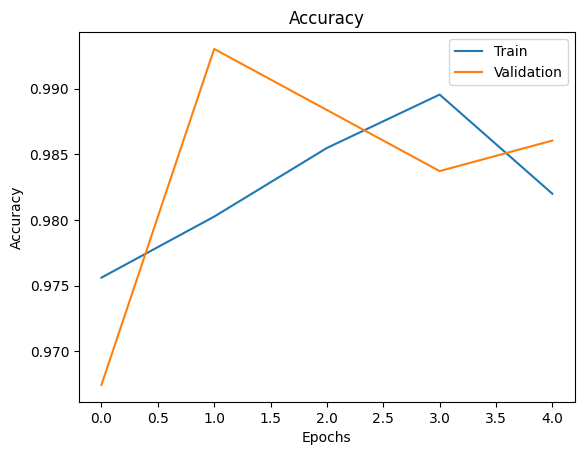

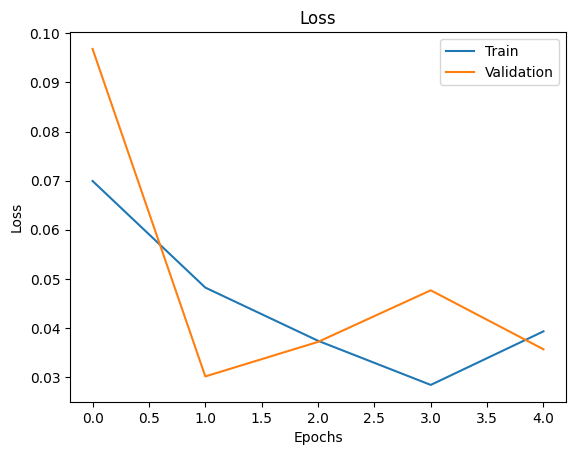

In [35]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

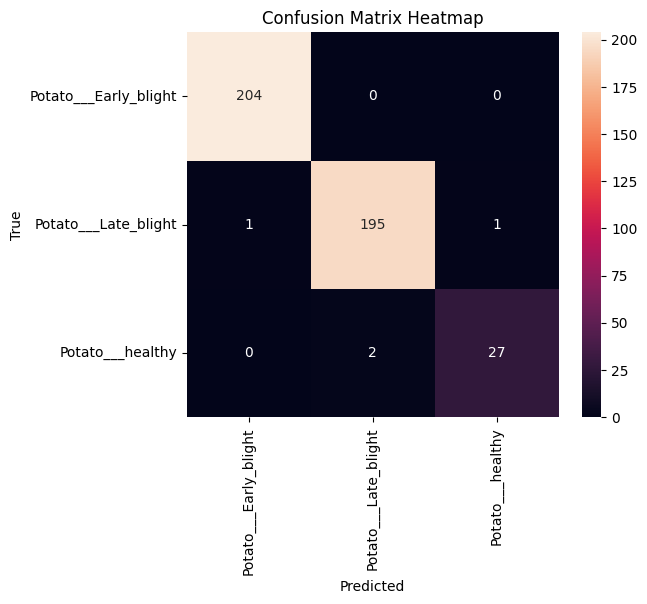

In [36]:
# Heatmap for confusion matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()